🔄 开始加载特征量...
✓ 成功加载 13 个特征文件

可用的特征:
  - te_dur_feat
  - tr_dur_feat
  - te_label_word
  - tr_label_phn
  - te_energy_feat
  - tr_label_utt
  - te_label_phn
  - te_label_utt
  - tr_energy_feat
  - tr_label_word
  - tr_word_id
  - te_feat
  - tr_feat



/tmp/ipykernel_101182/2941912022.py:180: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_101182/2941912022.py:180: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_101182/2941912022.py:180: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_101182/2941912022.py:180: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_101182/2941912022.py:180: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_101182/2941912022.py:180: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_101182/2941912022.py:180: UserW

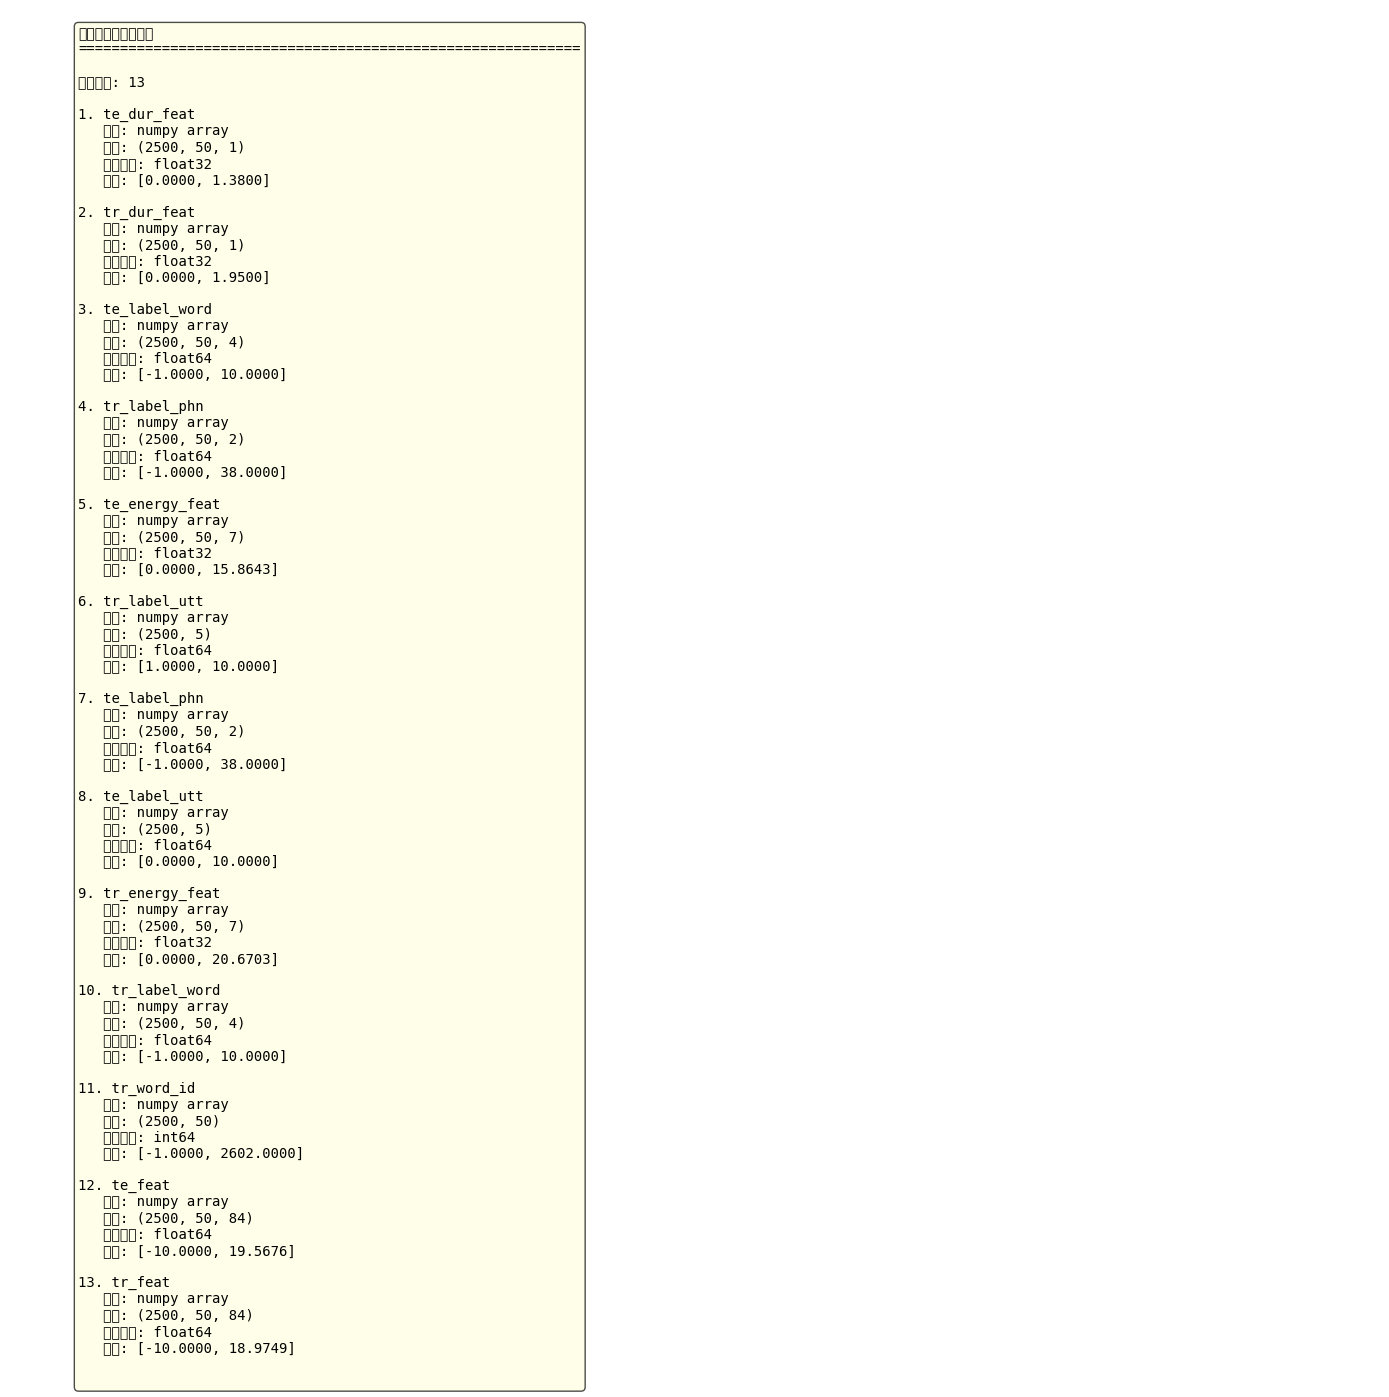

✓ 已保存总结报告

📊 可视化: te_dur_feat


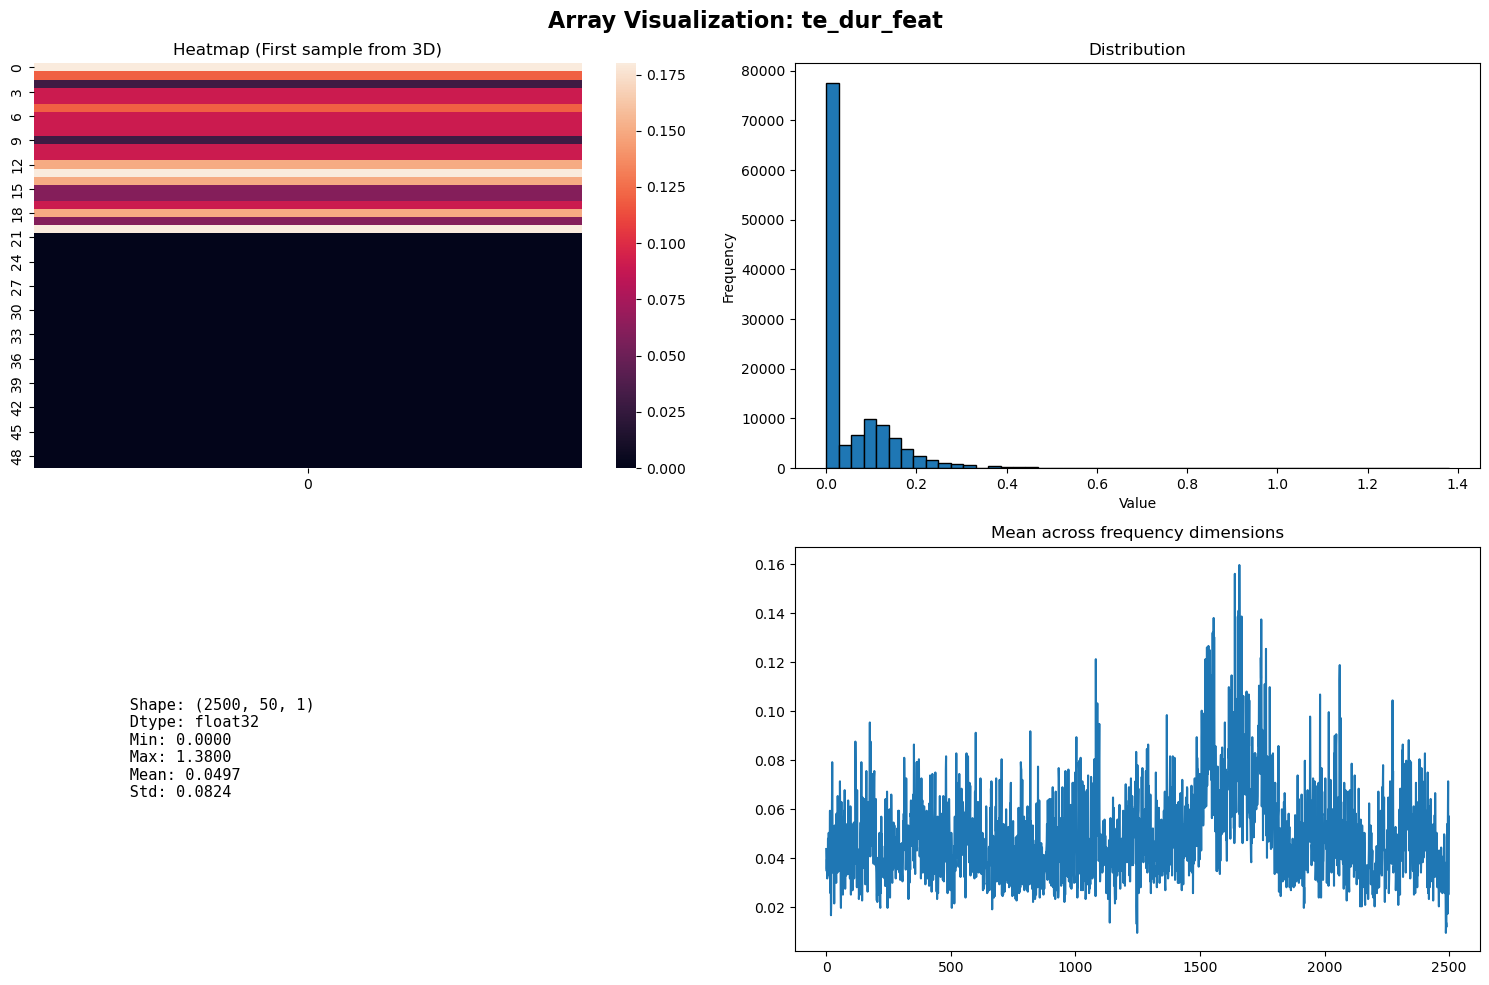

✓ 已保存可视化图到: /tmp/te_dur_feat_visualization.png

📊 可视化: tr_dur_feat


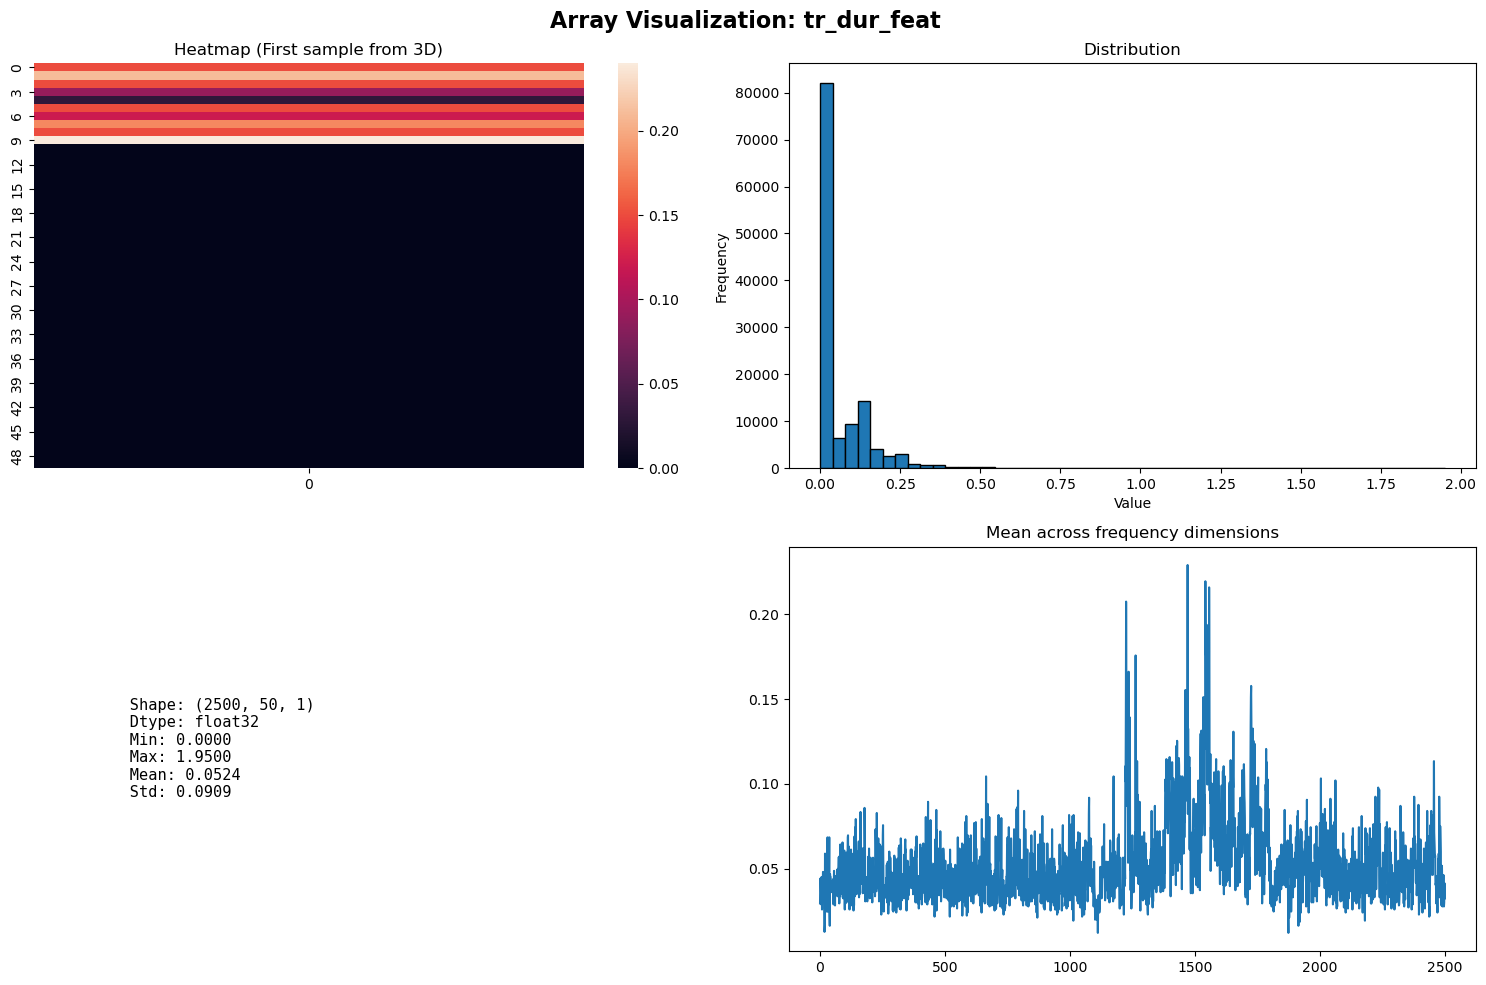

✓ 已保存可视化图到: /tmp/tr_dur_feat_visualization.png

📊 可视化: te_label_word


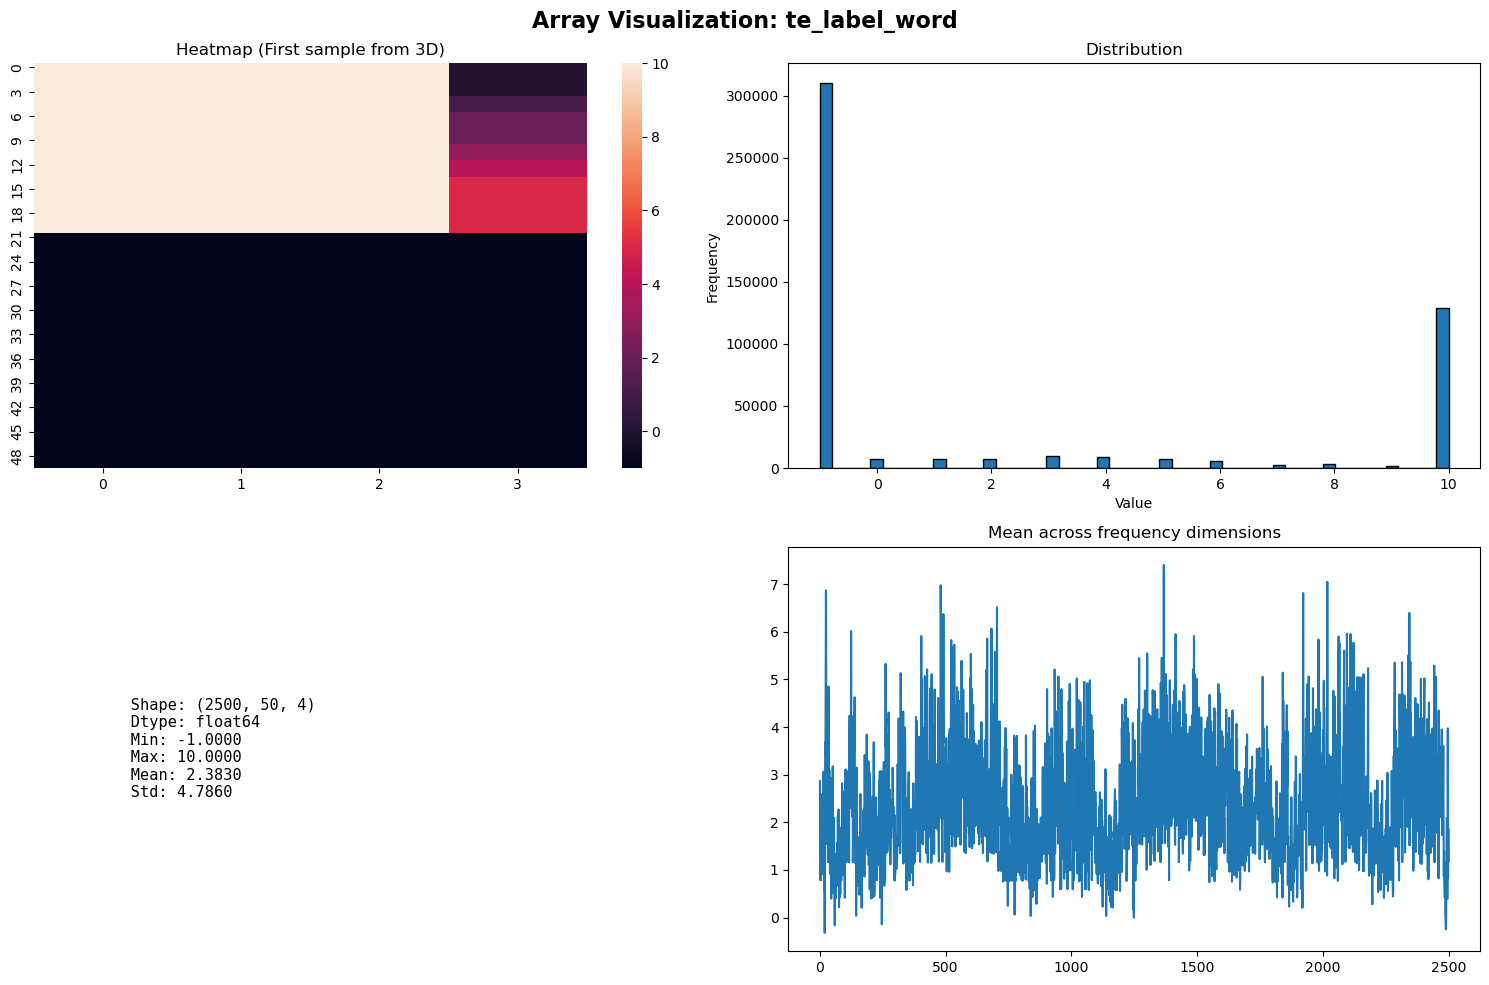

✓ 已保存可视化图到: /tmp/te_label_word_visualization.png

📊 可视化: tr_label_phn


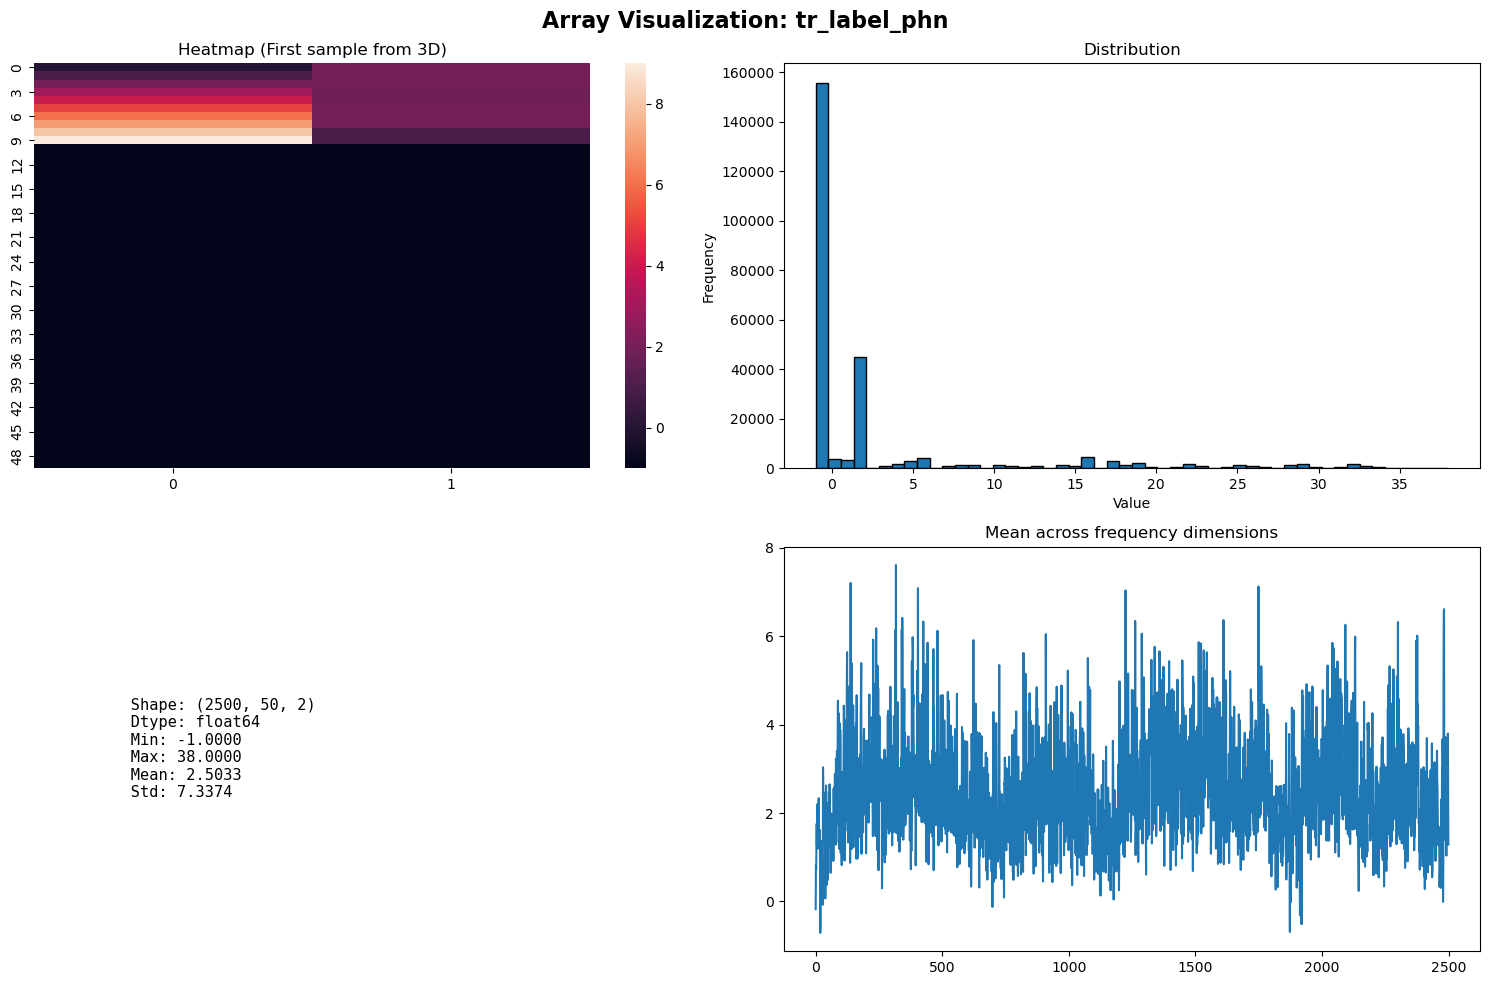

✓ 已保存可视化图到: /tmp/tr_label_phn_visualization.png

📊 可视化: te_energy_feat


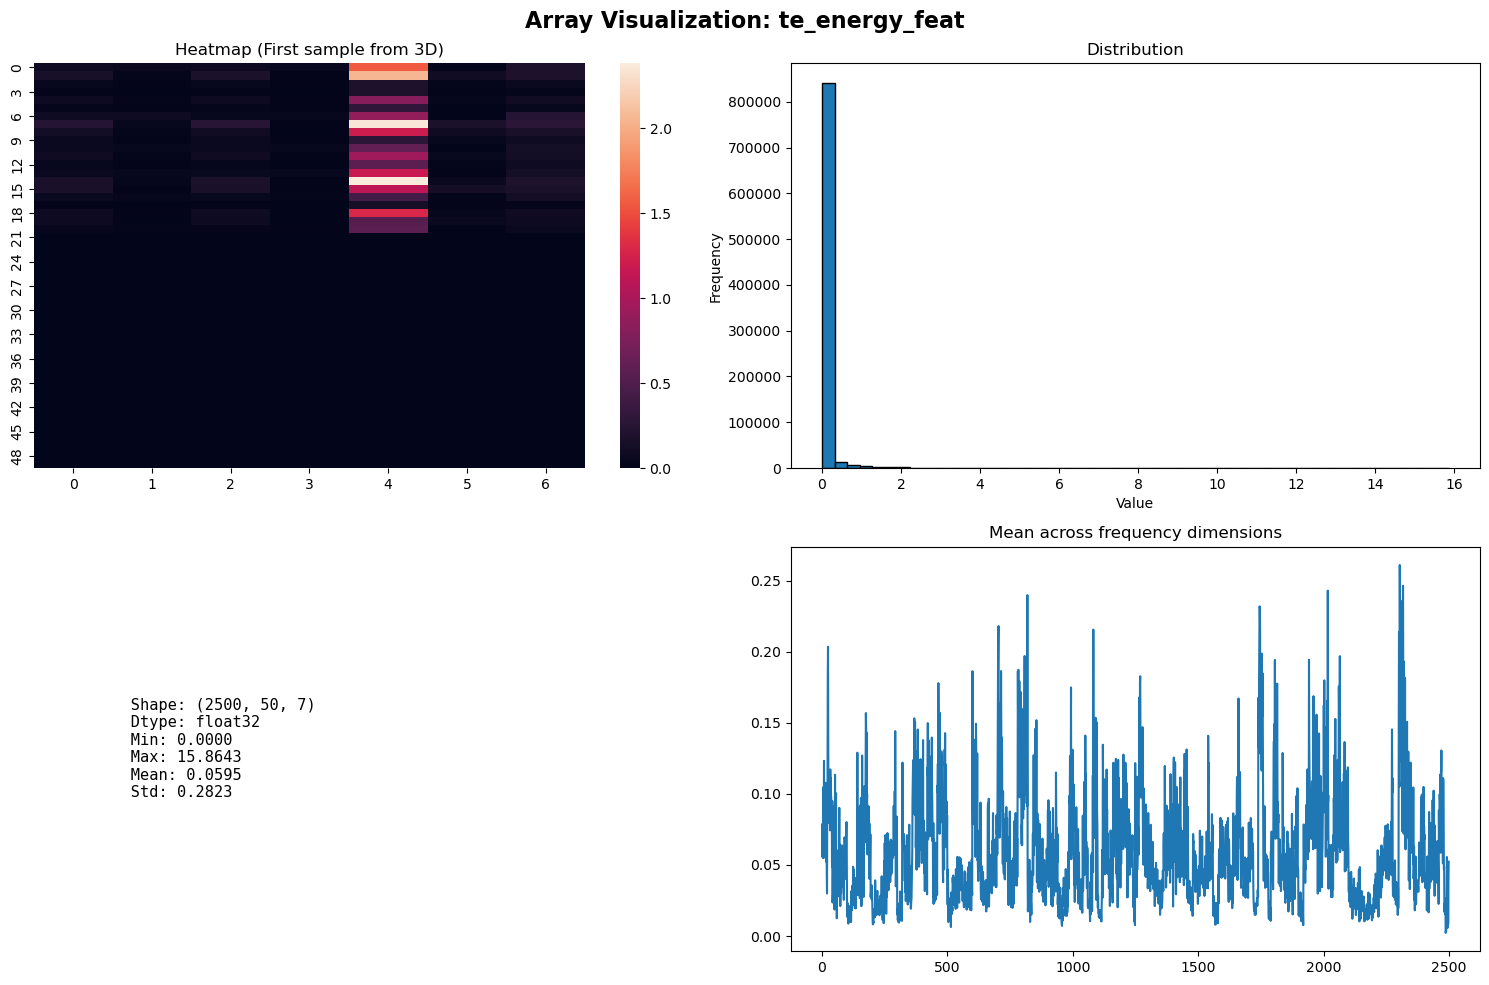

✓ 已保存可视化图到: /tmp/te_energy_feat_visualization.png

📊 可视化: tr_label_utt


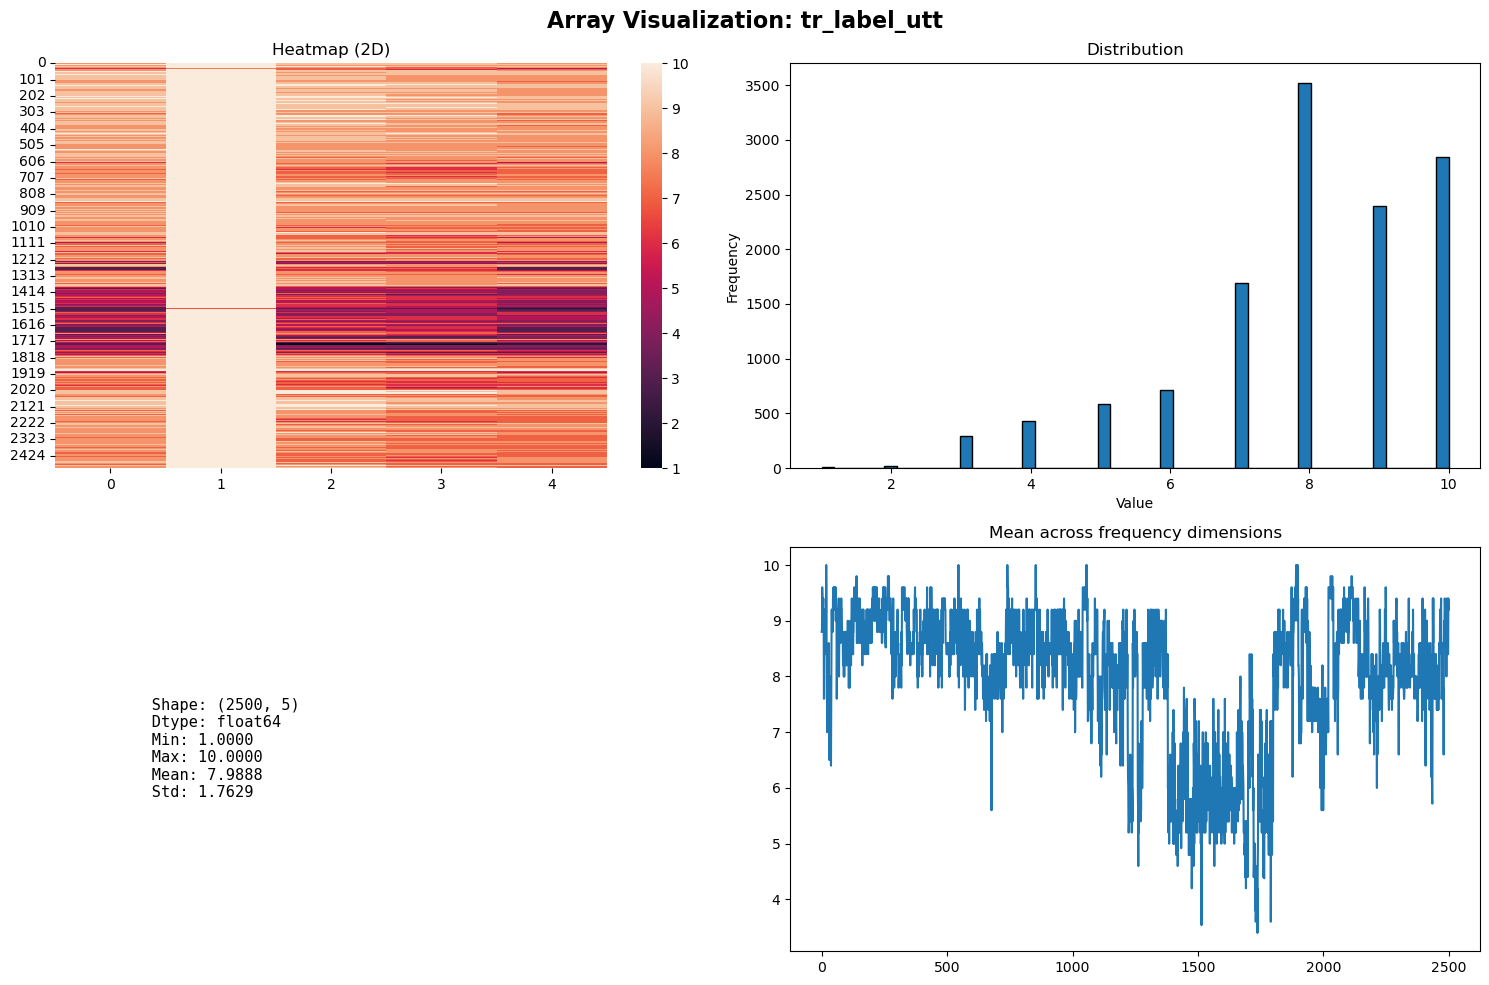

✓ 已保存可视化图到: /tmp/tr_label_utt_visualization.png

📊 可视化: te_label_phn


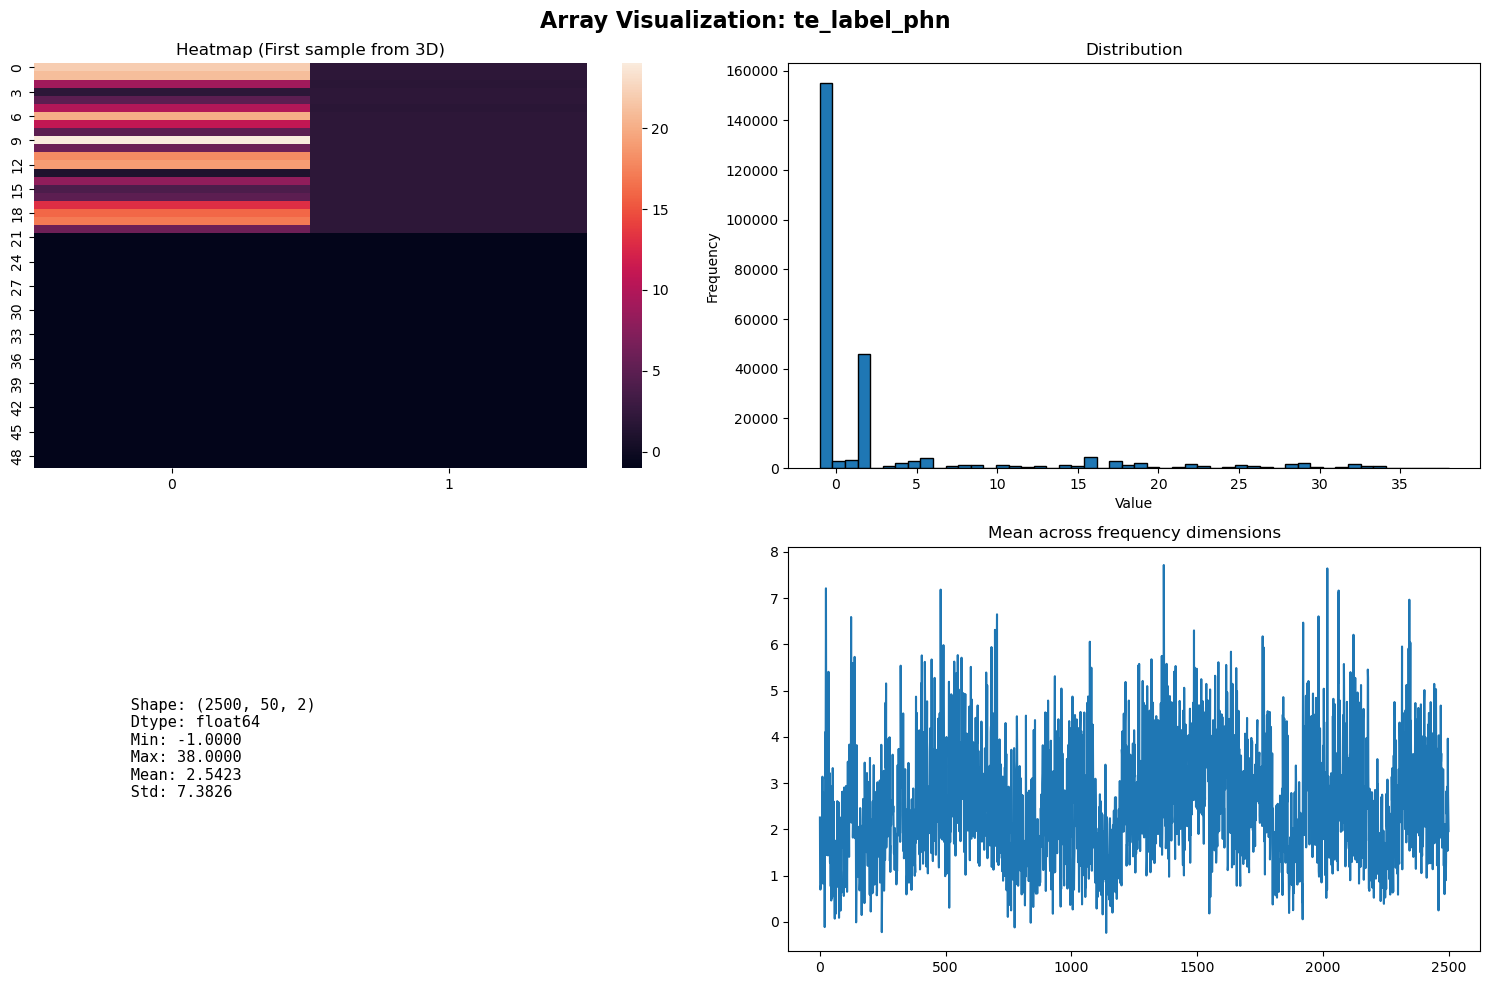

✓ 已保存可视化图到: /tmp/te_label_phn_visualization.png

📊 可视化: te_label_utt


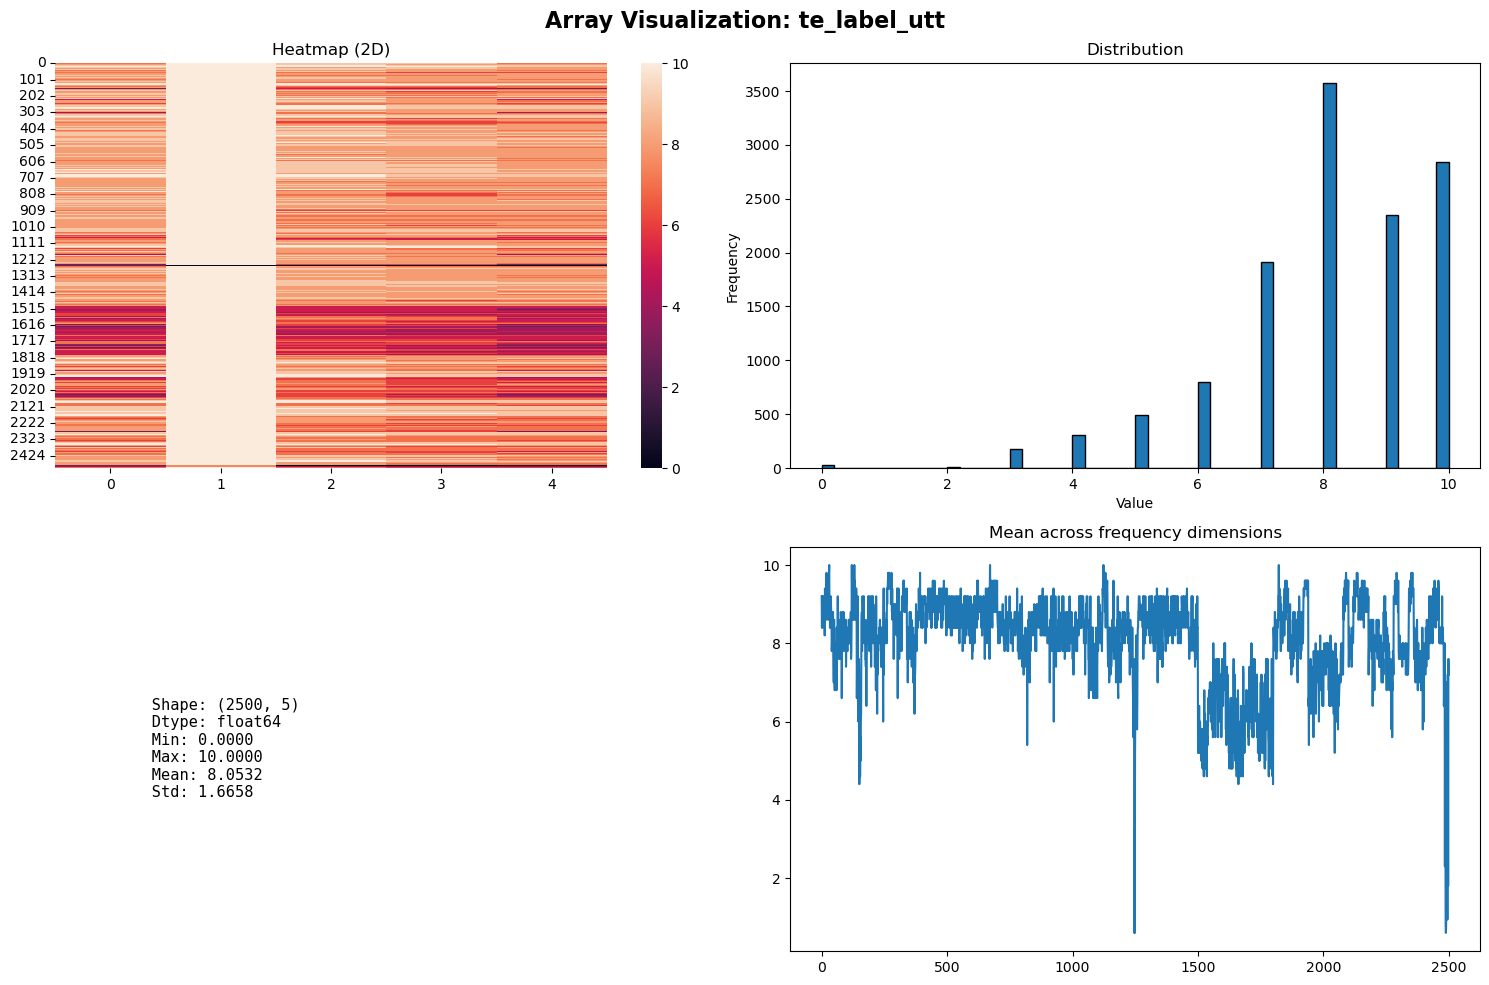

✓ 已保存可视化图到: /tmp/te_label_utt_visualization.png

📊 可视化: tr_energy_feat


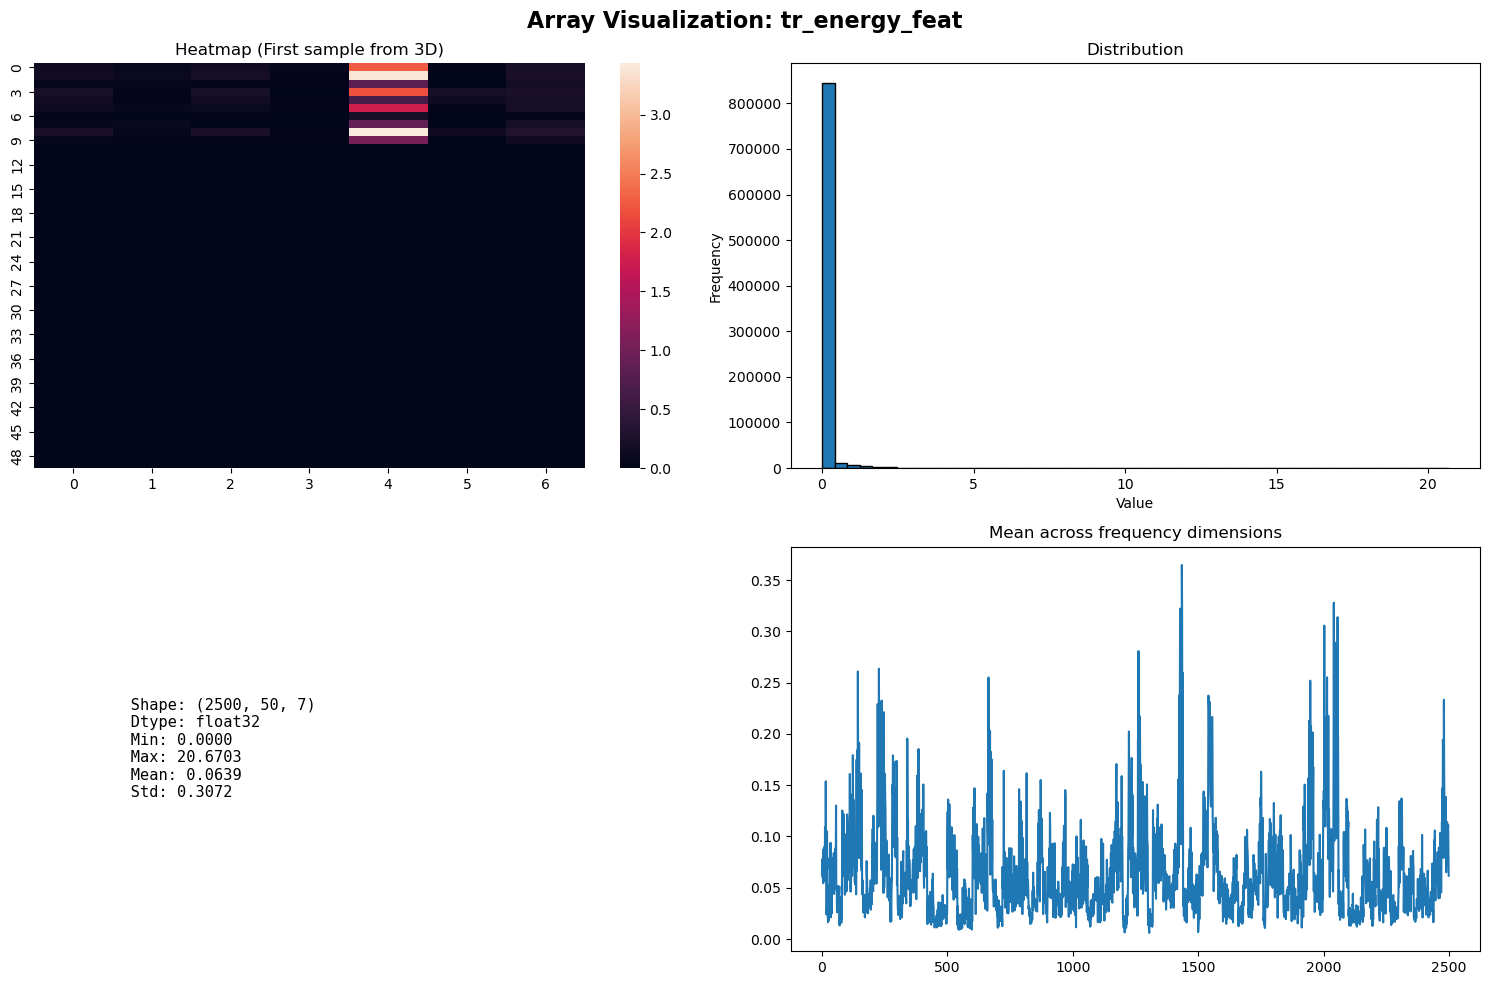

✓ 已保存可视化图到: /tmp/tr_energy_feat_visualization.png

📊 可视化: tr_label_word


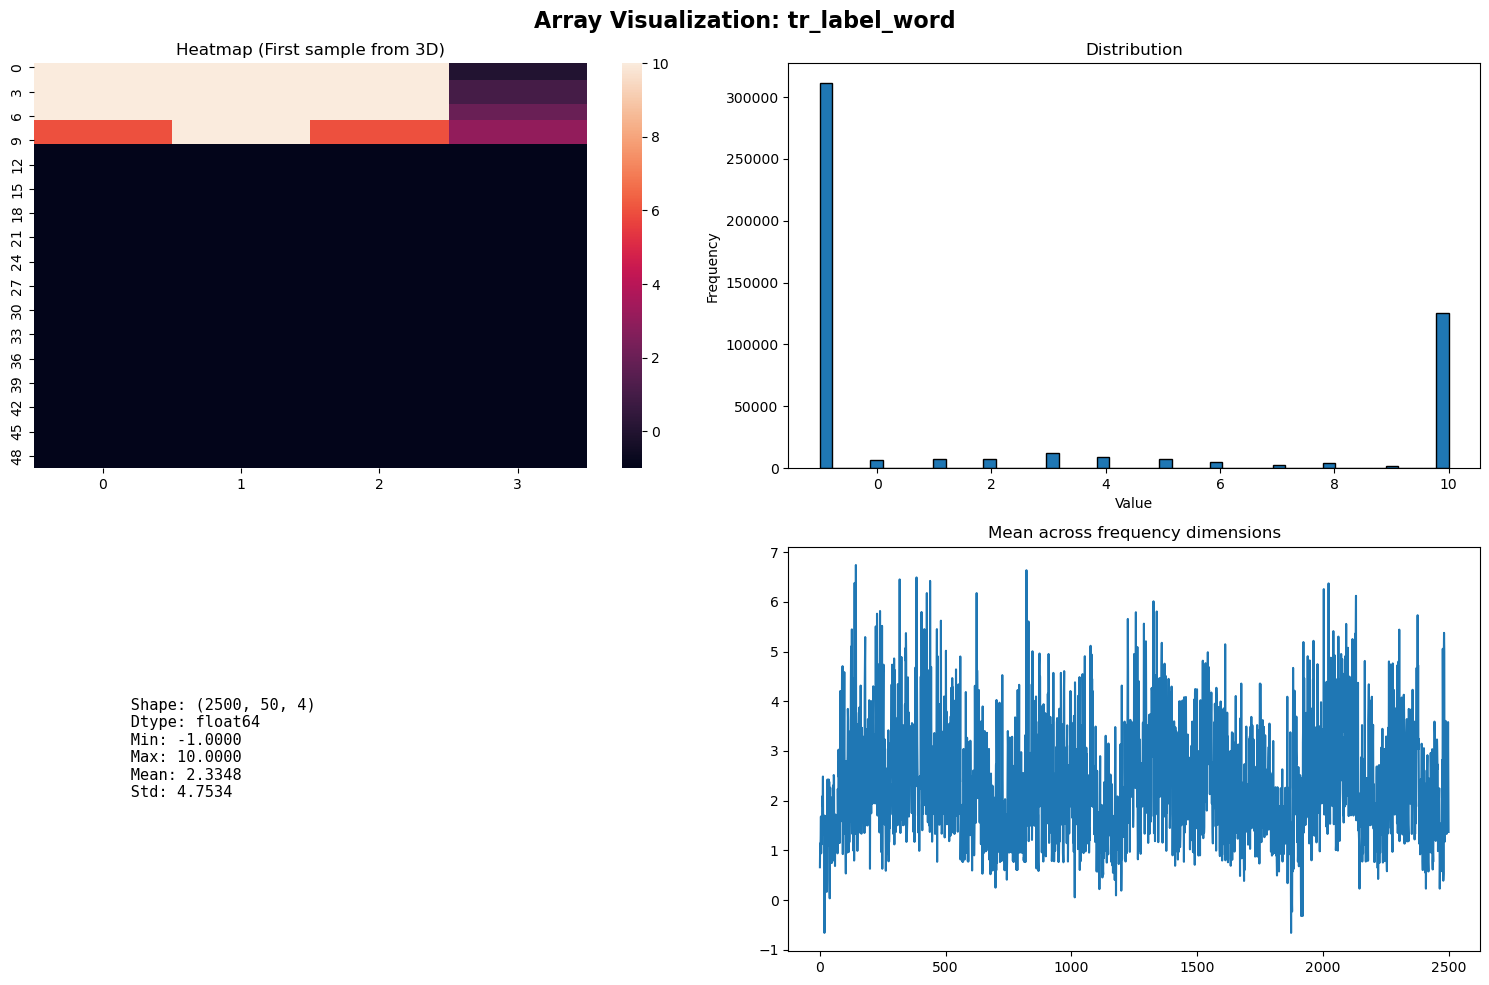

✓ 已保存可视化图到: /tmp/tr_label_word_visualization.png

📊 可视化: tr_word_id


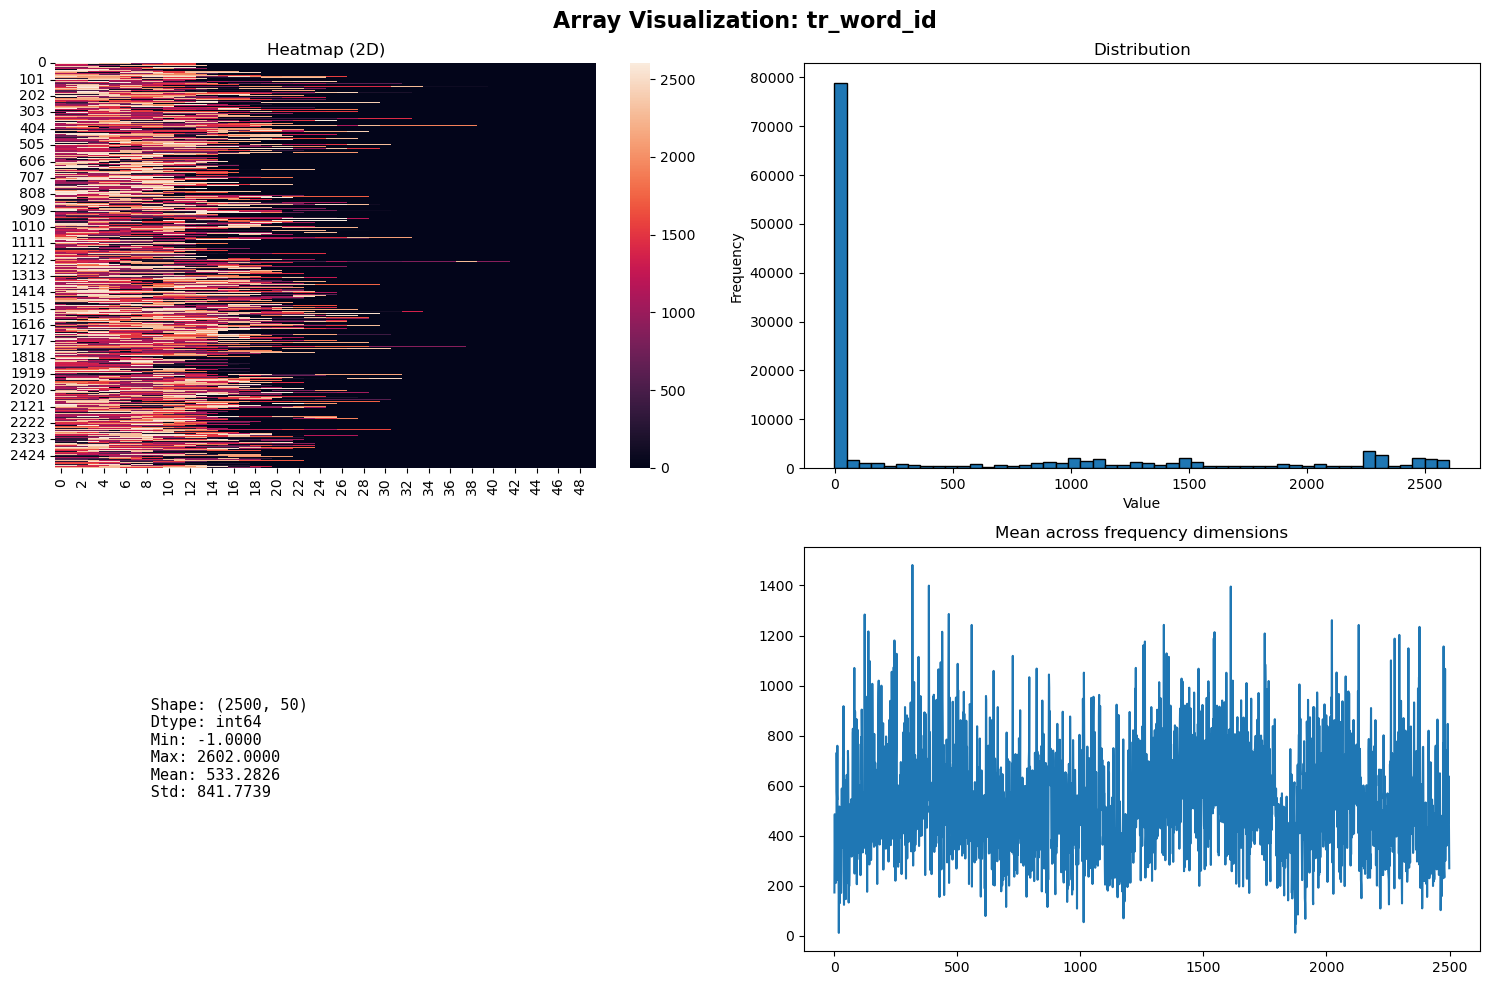

✓ 已保存可视化图到: /tmp/tr_word_id_visualization.png

📊 可视化: te_feat


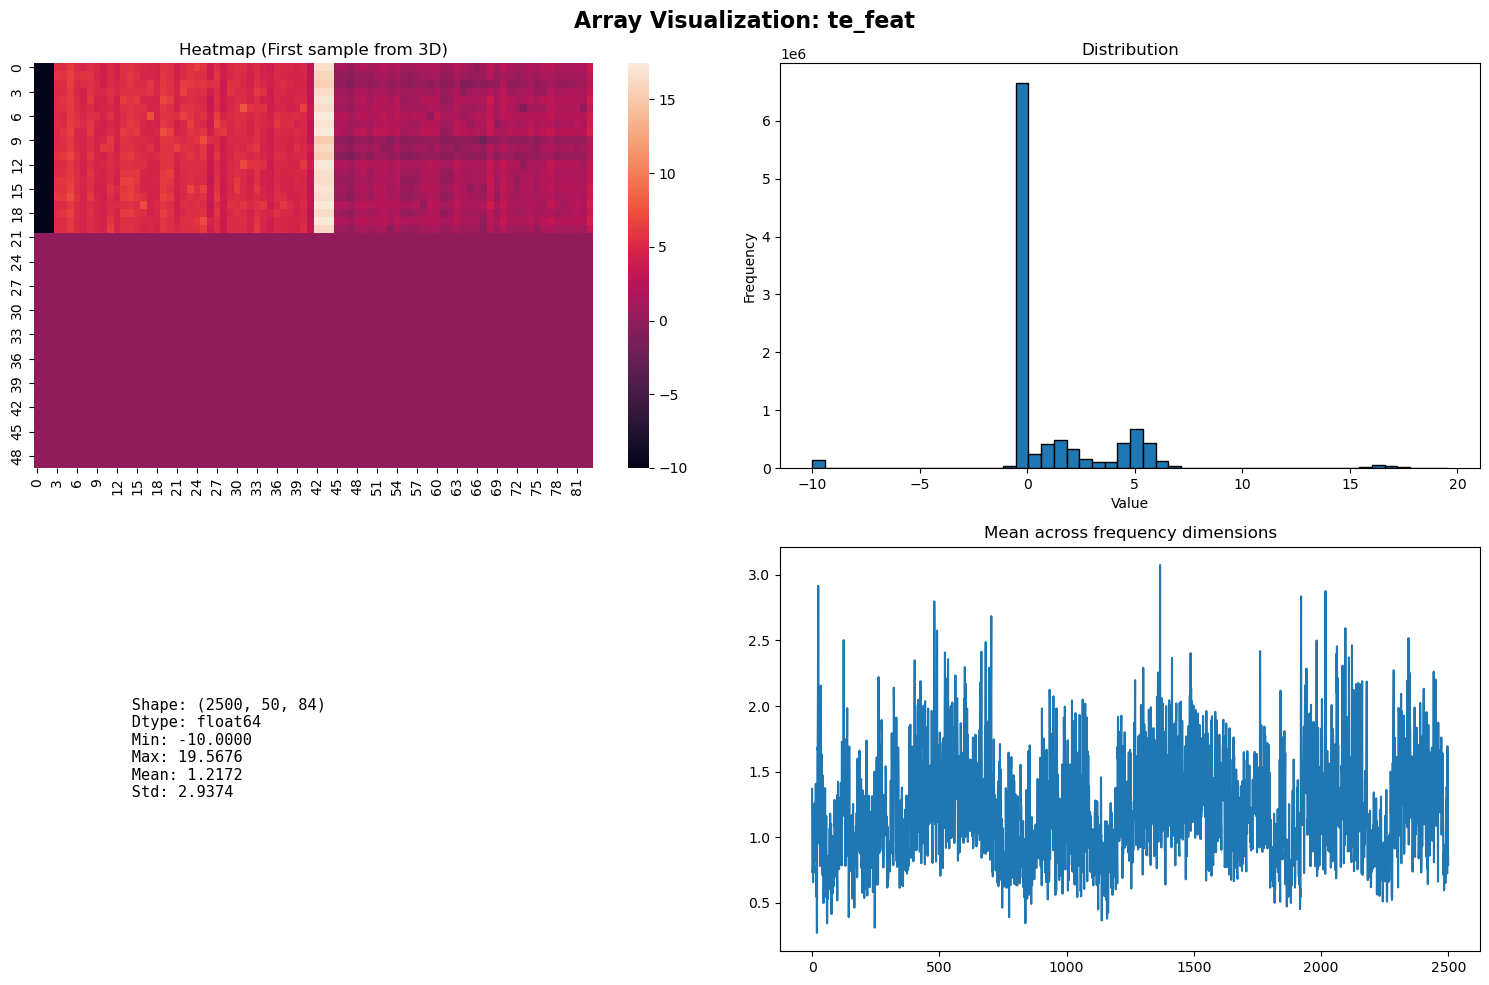

✓ 已保存可视化图到: /tmp/te_feat_visualization.png

📊 可视化: tr_feat


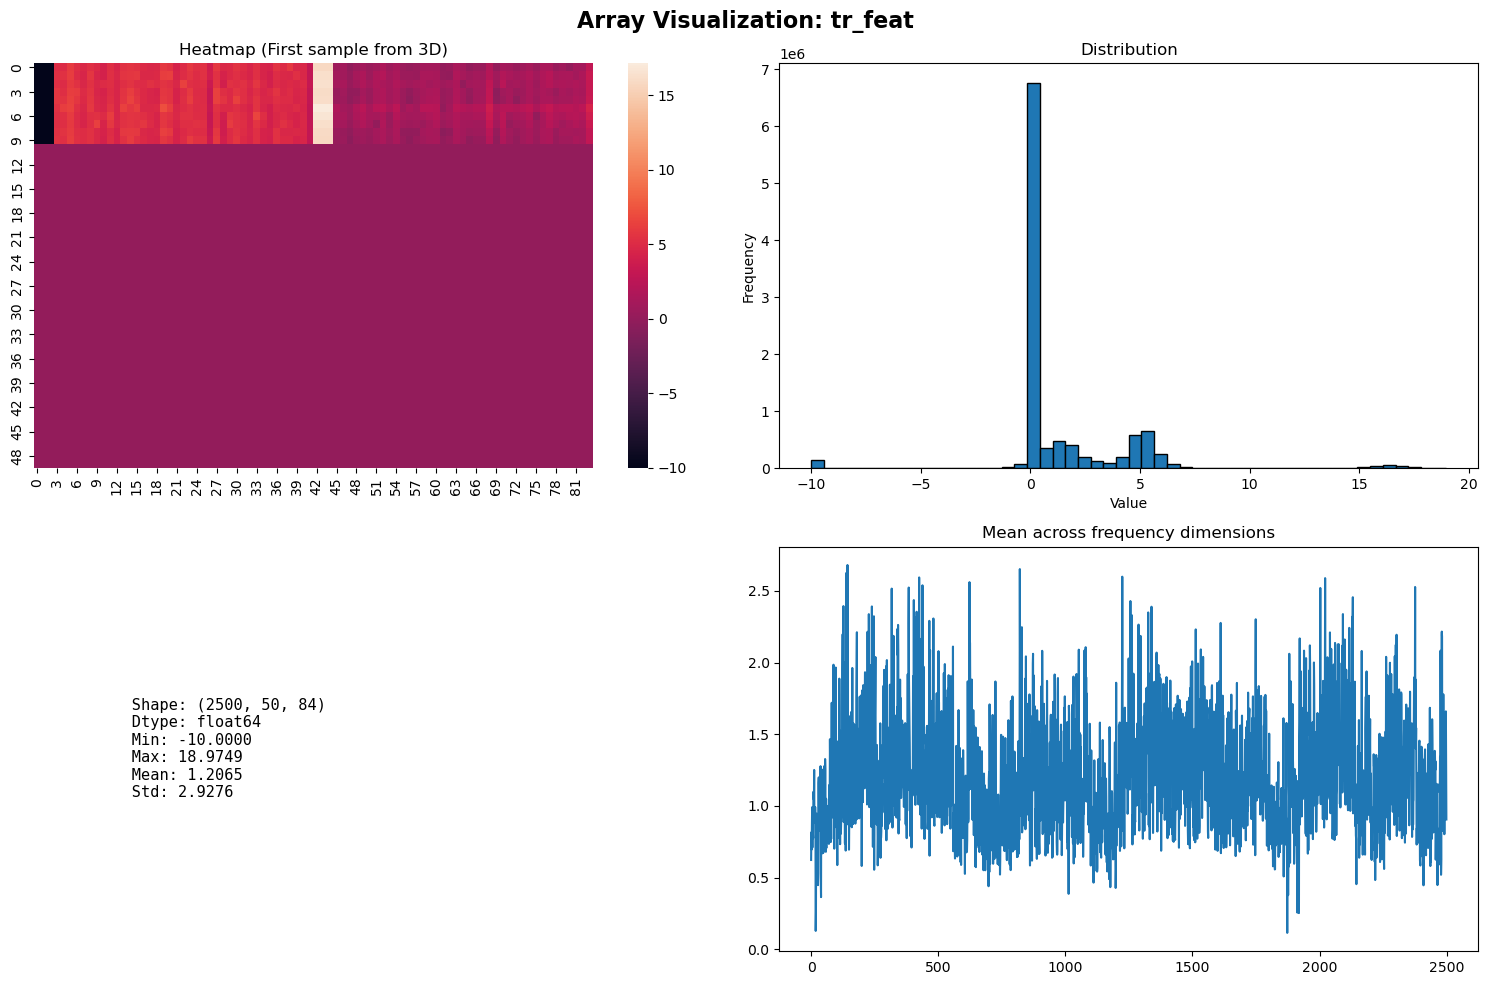

✓ 已保存可视化图到: /tmp/tr_feat_visualization.png

✓ 所有可视化已完成!


In [1]:
 # 基于参考文件的数据读取模式，这是一个完整的数据读取和可视化脚本

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle

# 设置数据路径
data_folder = Path("/home/kevingenghaopeng/MDD/IF-MDD/data_so762/hiertfr/seq_data_librispeech_v3")

def load_features_from_folder(data_folder):
    """从文件夹加载所有特征量"""
    features = {}
    
    # 支持多种文件格式
    for file_path in data_folder.glob("**/*"):
        if file_path.is_file():
            try:
                if file_path.suffix == '.npy':
                    # 加载numpy数组
                    features[file_path.stem] = np.load(file_path)
                    
                elif file_path.suffix == '.json':
                    # 加载JSON文件
                    with open(file_path, 'r', encoding='utf-8') as f:
                        features[file_path.stem] = json.load(f)
                        
                elif file_path.suffix == '.pkl':
                    # 加载pickle文件
                    with open(file_path, 'rb') as f:
                        features[file_path.stem] = pickle.load(f)
                        
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    return features

def visualize_features(features, feature_name=None):
    """可视化特征量"""
    
    if feature_name is None:
        # 如果没有指定，使用第一个特征
        feature_name = list(features.keys())[0]
    
    feature_data = features[feature_name]
    
    # 根据数据类型选择可视化方法
    if isinstance(feature_data, np.ndarray):
        visualize_array(feature_data, feature_name)
    elif isinstance(feature_data, dict):
        visualize_dict(feature_data, feature_name)
    elif isinstance(feature_data, list):
        visualize_list(feature_data, feature_name)

def visualize_array(array, title="Feature"):
    """可视化numpy数组"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Array Visualization: {title}', fontsize=16, fontweight='bold')
    
    # 1. 热力图（如果是2D）
    if array.ndim == 2:
        sns.heatmap(array, ax=axes[0, 0], cbar=True)
        axes[0, 0].set_title('Heatmap (2D)')
    elif array.ndim == 3:
        # 取第一个样本的热力图
        sns.heatmap(array[0], ax=axes[0, 0], cbar=True)
        axes[0, 0].set_title(f'Heatmap (First sample from 3D)')
    else:
        axes[0, 0].plot(array.flatten()[:1000])
        axes[0, 0].set_title('Signal (First 1000 values)')
    
    # 2. 直方图
    axes[0, 1].hist(array.flatten(), bins=50, edgecolor='black')
    axes[0, 1].set_title('Distribution')
    axes[0, 1].set_xlabel('Value')
    axes[0, 1].set_ylabel('Frequency')
    
    # 3. 统计信息
    stats_text = f"""
    Shape: {array.shape}
    Dtype: {array.dtype}
    Min: {array.min():.4f}
    Max: {array.max():.4f}
    Mean: {array.mean():.4f}
    Std: {array.std():.4f}
    """
    axes[1, 0].text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
                    verticalalignment='center')
    axes[1, 0].axis('off')
    
    # 4. 时间序列或光谱图
    if array.ndim >= 2:
        if array.shape[0] < 500:  # 时间步数较少
            sns.heatmap(array, ax=axes[1, 1], cbar=True, cmap='viridis')
            axes[1, 1].set_title('Spectrogram-like view')
        else:
            axes[1, 1].plot(array.mean(axis=tuple(range(1, array.ndim))))
            axes[1, 1].set_title('Mean across frequency dimensions')
    
    plt.tight_layout()
    plt.savefig(f'/tmp/{title}_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✓ 已保存可视化图到: /tmp/{title}_visualization.png")

def visualize_dict(data_dict, title="Feature"):
    """可视化字典数据"""
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # 显示字典的键和值
    text = f"Dictionary: {title}\n\n"
    for key, value in data_dict.items():
        if isinstance(value, (int, float, str)):
            text += f"{key}: {value}\n"
        elif isinstance(value, np.ndarray):
            text += f"{key}: ndarray{value.shape}\n"
        elif isinstance(value, (list, dict)):
            text += f"{key}: {type(value).__name__}\n"
    
    ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'/tmp/{title}_dict_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

def visualize_list(data_list, title="Feature"):
    """可视化列表数据"""
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    text = f"List: {title}\nLength: {len(data_list)}\n\nFirst 10 items:\n"
    for i, item in enumerate(data_list[:10]):
        text += f"[{i}]: {item}\n"
    
    if len(data_list) > 10:
        text += f"... and {len(data_list) - 10} more items"
    
    ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'/tmp/{title}_list_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

def create_summary_report(features):
    """创建特征总结报告"""
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    report = "特征量数据总结报告\n" + "="*60 + "\n\n"
    report += f"总特征数: {len(features)}\n\n"
    
    for i, (name, data) in enumerate(features.items()):
        if isinstance(data, np.ndarray):
            report += f"{i+1}. {name}\n"
            report += f"   类型: numpy array\n"
            report += f"   形状: {data.shape}\n"
            report += f"   数据类型: {data.dtype}\n"
            report += f"   范围: [{data.min():.4f}, {data.max():.4f}]\n\n"
        else:
            report += f"{i+1}. {name}\n"
            report += f"   类型: {type(data).__name__}\n"
            report += f"   大小: {len(data) if hasattr(data, '__len__') else 'N/A'}\n\n"
    
    ax.text(0.05, 0.95, report, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('/tmp/features_summary_report.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ 已保存总结报告")

# 主程序
if __name__ == "__main__":
    print("🔄 开始加载特征量...")
    features = load_features_from_folder(data_folder)
    
    print(f"✓ 成功加载 {len(features)} 个特征文件")
    print("\n可用的特征:")
    for name in features.keys():
        print(f"  - {name}")
    
    print("\n" + "="*60)
    
    # 创建总结报告
    create_summary_report(features)
    
    # 可视化每个特征
    for feature_name in features.keys():
        print(f"\n📊 可视化: {feature_name}")
        visualize_features(features, feature_name)
    
    print("\n✓ 所有可视化已完成!")

In [ ]:
train_set_dict = {
    "feat": "data_so762/hiertfr/seq_data_librispeech_v3/tr_feat.npy",
    "enerey": "data_so762/hiertfr/seq_data_librispeech_v3/tr_enerey.npy",
    "dur": "data_so762/hiertfr/seq_data_librispeech_v3/tr_dur.npy",
    "tr_label_phn": "data_so762/hiertfr/seq_data_librispeech_v3/tr_label_phn.npy",
    "tr_label_word": "data_so762/hiertfr/seq_data_librispeech_v3/tr_label_word.npy",
    "tr_label_utt": "data_so762/hiertfr/seq_data_librispeech_v3/tr_label_utt.npy"
}

test_set_dict  {
    "feat": "data_so762/hiertfr/seq_data_librispeech_v3/te_feat.npy",
    "enerey": "data_so762/hiertfr/seq_data_librispeech_v3/te_enerey.npy",
    "dur": "data_so762/hiertfr/seq_data_librispeech_v3/te_dur.npy",
    "te_label_phn": "data_so762/hiertfr/seq_data_librispeech_v3/te_label_phn.npy",
    "te_label_word": "data_so762/hiertfr/seq_data_librispeech_v3/te_label_word.npy",
    "te_label_utt": "data_so762/hiertfr/seq_data_librispeech_v3/te_label_utt.npy"
}

train_wav_scp= "/home/kevingenghaopeng/Tools/kaldi/egs/gop_speechocean762/s5/data/train/wav.scp"
test_wav_scp= "/home/kevingenghaopeng/Tools/kaldi/egs/gop_speechocean762/s5/data/test/wav.scp"

In [10]:
# assert train set and train_wav_scp have the same number of utterances, and in the same order
# merge them
def merge_wav_scp_with_features(wav_scp_path, features_dict, prefix="tr_"):
    """将wav.scp与特征量字典合并"""
    merged_data = {}
    
    # 读取wav.scp文件
    with open(wav_scp_path, 'r', encoding='utf-8') as f:
        wav_lines = f.readlines()
    
    # 提取utterance IDs
    utt_ids = [line.split()[0] for line in wav_lines]
    
    # 确保特征量的顺序与wav.scp一致
    for i, utt_id in enumerate(utt_ids):
        merged_data[utt_id] = {}
        for key, path in features_dict.items():
            feature_key = key.replace(prefix, "")
            merged_data[utt_id][feature_key] = features_dict[key][i]
    
    return merged_data



In [17]:

train_wav_scp = "/home/kevingenghaopeng/Tools/kaldi/egs/gop_speechocean762/s5/data/train/wav.scp"

In [18]:
train_data = merge_wav_scp_with_features(train_wav_scp, train_set_dict, prefix="tr_")

NameError: name 'train_set_dict' is not defined